In [38]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from skimage.feature import hog

---------------------------------------------------------------------------------------------- Dataset Understanding and extract features
 ---------------------------------------------------------------------------------------------

In [39]:
base_path = r"D:\hady\3nd year\Second_term\Supervised_Learning\project\GTSRB"
train_csv = os.path.join(base_path, "Train.csv")
test_csv  = os.path.join(base_path, "Test.csv")
target_size = (32, 32)

train_data = pd.read_csv(train_csv)
test_data  = pd.read_csv(test_csv)

def load_and_extract_features(csv_file):
    data = pd.read_csv(csv_file)
    features_list = []
    labels_list = []
    images = []
    labels = []
    for idx, row in data.iterrows():
        img_path = os.path.join(base_path, row['Path'])
        class_id = row['ClassId']
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, target_size)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) 
            features = hog(gray, orientations=9, pixels_per_cell=(8,8), 
                           cells_per_block=(2,2), block_norm='L2-Hys')
            features_list.append(features)
            labels_list.append(class_id)
            images.append(img)
            labels.append(class_id)
    features_array = np.array(features_list, dtype='float32')
    labels_array = np.array(labels_list, dtype='int')
    images = np.array(images, dtype='float32') / 255.0  # normalize 0-1
    labels = np.array(labels)
    return features_array, labels_array,images, labels


X_train_feat, y_train_feat,X_train, y_train = load_and_extract_features(train_csv)
X_test_feat, y_test_feat,X_test, y_test   = load_and_extract_features(test_csv)


print("✅ Training set:")
print("Number of images:", X_train_feat.shape[0])
print("Number of classes:", len(np.unique(y_train_feat)))
print("Example labels:", np.unique(y_train_feat))
print("Sample structure (first 5 rows of CSV):")
print(train_data.head())

print("\n✅ Test set:")
print("Number of images:", X_test_feat.shape[0])
print("Number of classes:", len(np.unique(y_test_feat)))
print("Example labels:", np.unique(y_test_feat))
print("Sample structure (first 5 rows of CSV):")
print(test_data.head())

✅ Training set:
Number of images: 39209
Number of classes: 43
Example labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]
Sample structure (first 5 rows of CSV):
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  

✅ Test set:
Number of images: 12630
Number of classes: 43
Example labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 

---------------------------------------------------------------------------------------------- Exploratory Data Analysis (EDA)
 ---------------------------------------------------------------------------------------------

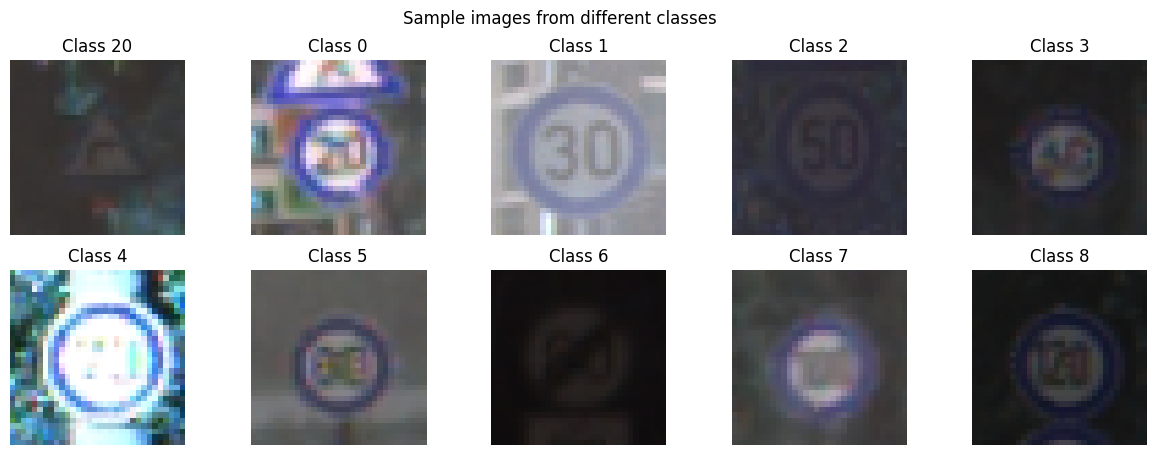

In [40]:
def show_samples(x,y,num_image = 5):
    plt.figure(figsize=(15, 5))
    classes_shown = 0
    seen_classes = set()
    
    for img, label in zip(x, y):
        if label not in seen_classes:
            plt.subplot(2, 5, classes_shown+1)
            plt.imshow(img)
            plt.title(f"Class {label}")
            plt.axis('off')
            seen_classes.add(label)
            classes_shown += 1
        if classes_shown >= num_image:
            break
    plt.suptitle("Sample images from different classes")
    plt.show()

show_samples(X_train, y_train, num_image=10)

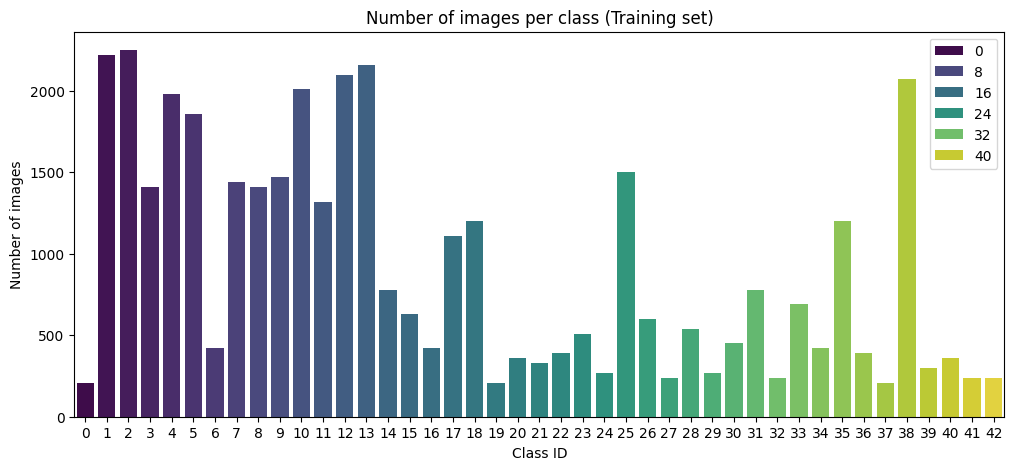

In [41]:
train_classes, train_counts = np.unique(y_train_feat, return_counts=True)
plt.figure(figsize=(12,5))
sns.barplot(x=train_classes, y=train_counts, palette="viridis" , hue=train_classes)
plt.title("Number of images per class (Training set)")
plt.xlabel("Class ID")
plt.ylabel("Number of images")
plt.show()

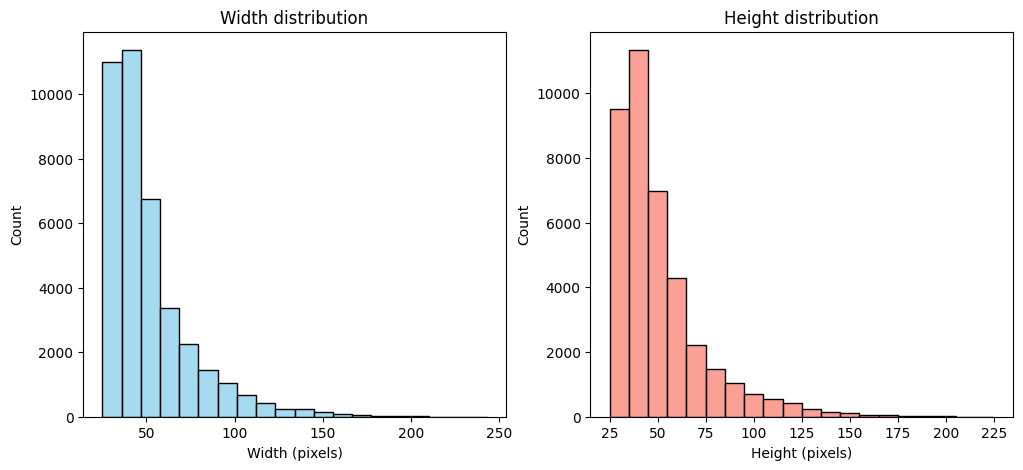

In [42]:
widths = train_data['Width']
heights = train_data['Height']

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(widths, bins=20, color='skyblue')
plt.title("Width distribution")
plt.xlabel("Width (pixels)")

plt.subplot(1,2,2)
sns.histplot(heights, bins=20, color='salmon')
plt.title("Height distribution")
plt.xlabel("Height (pixels)")

plt.show()

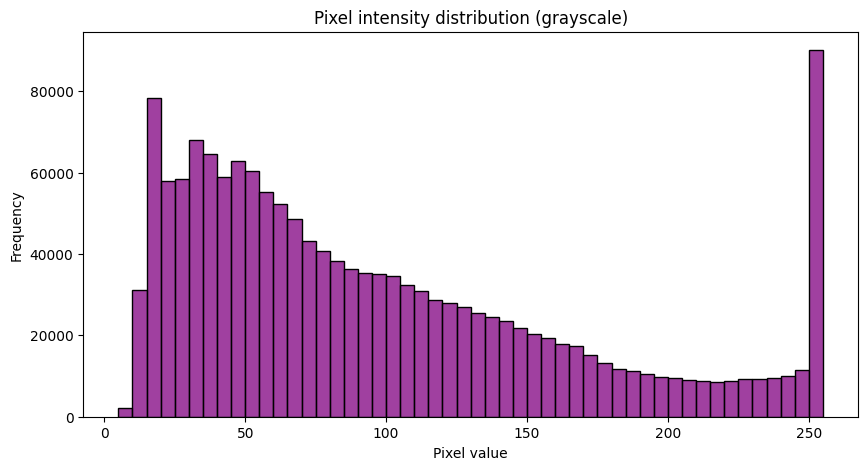

In [44]:
sample_images = X_train[:1500]
pixel_values = np.array([cv2.cvtColor((img*255).astype('uint8'), cv2.COLOR_RGB2GRAY).flatten()
                         for img in sample_images])
pixel_values = pixel_values.flatten()

plt.figure(figsize=(10,5))
sns.histplot(pixel_values, bins=50, color='purple')
plt.title("Pixel intensity distribution (grayscale)")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.show()

---------------------------------------------------------------------------------------------- Feature extraction 
 ---------------------------------------------------------------------------------------------

In [45]:
np.save("X_train_hog.npy", X_train_feat)
np.save("y_train_hog.npy", y_train_feat)
np.save("X_test_hog.npy", X_test_feat)
np.save("y_test_hog.npy", y_test_feat)

print("HOG features saved successfully!")

HOG features saved successfully!
